In [1]:
import pandas as pd

DATA CLEANING:

In [2]:
# Load df and initially look at data
df = pd.read_csv("dataset.csv")

initial_rows = df.shape[0]
print(initial_rows)
print(df.columns)
df.head()


114000
Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [4]:
# Check for invalid values and drop
print(df.isna().sum())
df = df.dropna()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [5]:
# Confirm drops successful
after_null_drops_rows = df.shape[0]
rows_dropped_from_null_drop = initial_rows-after_null_drops_rows
print(f"Number of rows dropped from removing null, NA, etc values: {rows_dropped_from_null_drop}")
df.isna().sum()


Number of rows dropped from removing null, NA, etc values: 1


Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [6]:
#Check for any duplicates
# df.duplicated().sum()
df = df.drop_duplicates()
after_duplicate_drop_rows = df.shape[0]
rows_dropped_from_duplicate_drop = after_null_drops_rows- after_duplicate_drop_rows
print(f"Number of rows dropped from removing duplicates: {rows_dropped_from_duplicate_drop}")

Number of rows dropped from removing duplicates: 0


VISUALIZATION:

In [7]:
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

<Axes: xlabel='popularity', ylabel='Count'>

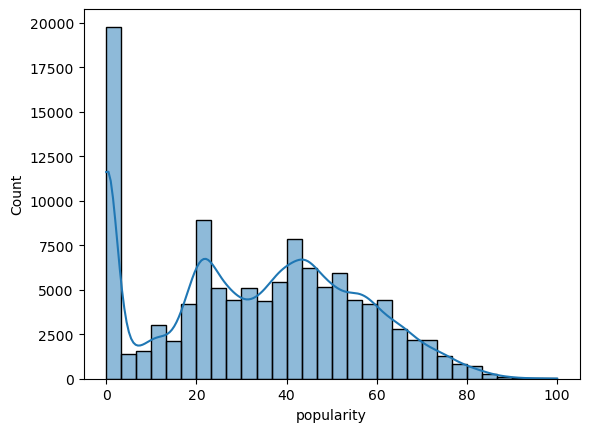

In [8]:
sns.histplot(data=df, x='popularity',bins=30,kde=True)

We filter our dataset to remove songs with 0 popularity 

<Axes: xlabel='popularity', ylabel='Count'>

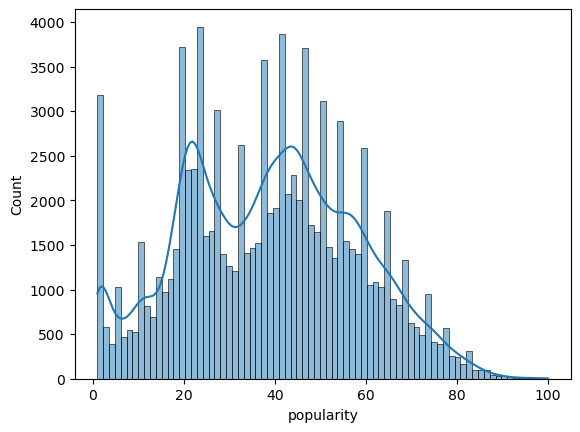

In [9]:
popularity_filtered_df = df[df['popularity'] != 0]

sns.histplot(data=popularity_filtered_df, x='popularity',bins='auto',kde=True)

Alone, these attributes seem to not predict very well which is expected, since its a combination of features that work together to create a popular song

Text(0.5, 1.0, 'Popularity vs Loudness')

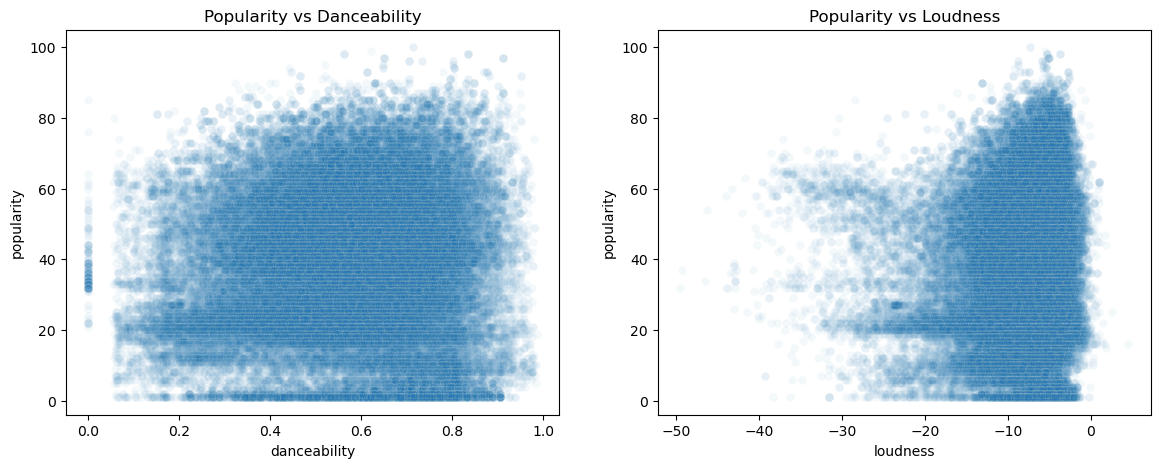

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Using alpha=0.05 because you have 114k rows!
sns.scatterplot(data=popularity_filtered_df, x='danceability', y='popularity', alpha=0.05, ax=axes[0])
axes[0].set_title('Popularity vs Danceability')

sns.scatterplot(data=popularity_filtered_df, x='loudness', y='popularity', alpha=0.05, ax=axes[1])
axes[1].set_title('Popularity vs Loudness')

With pairplot we can see the distributions of each variable

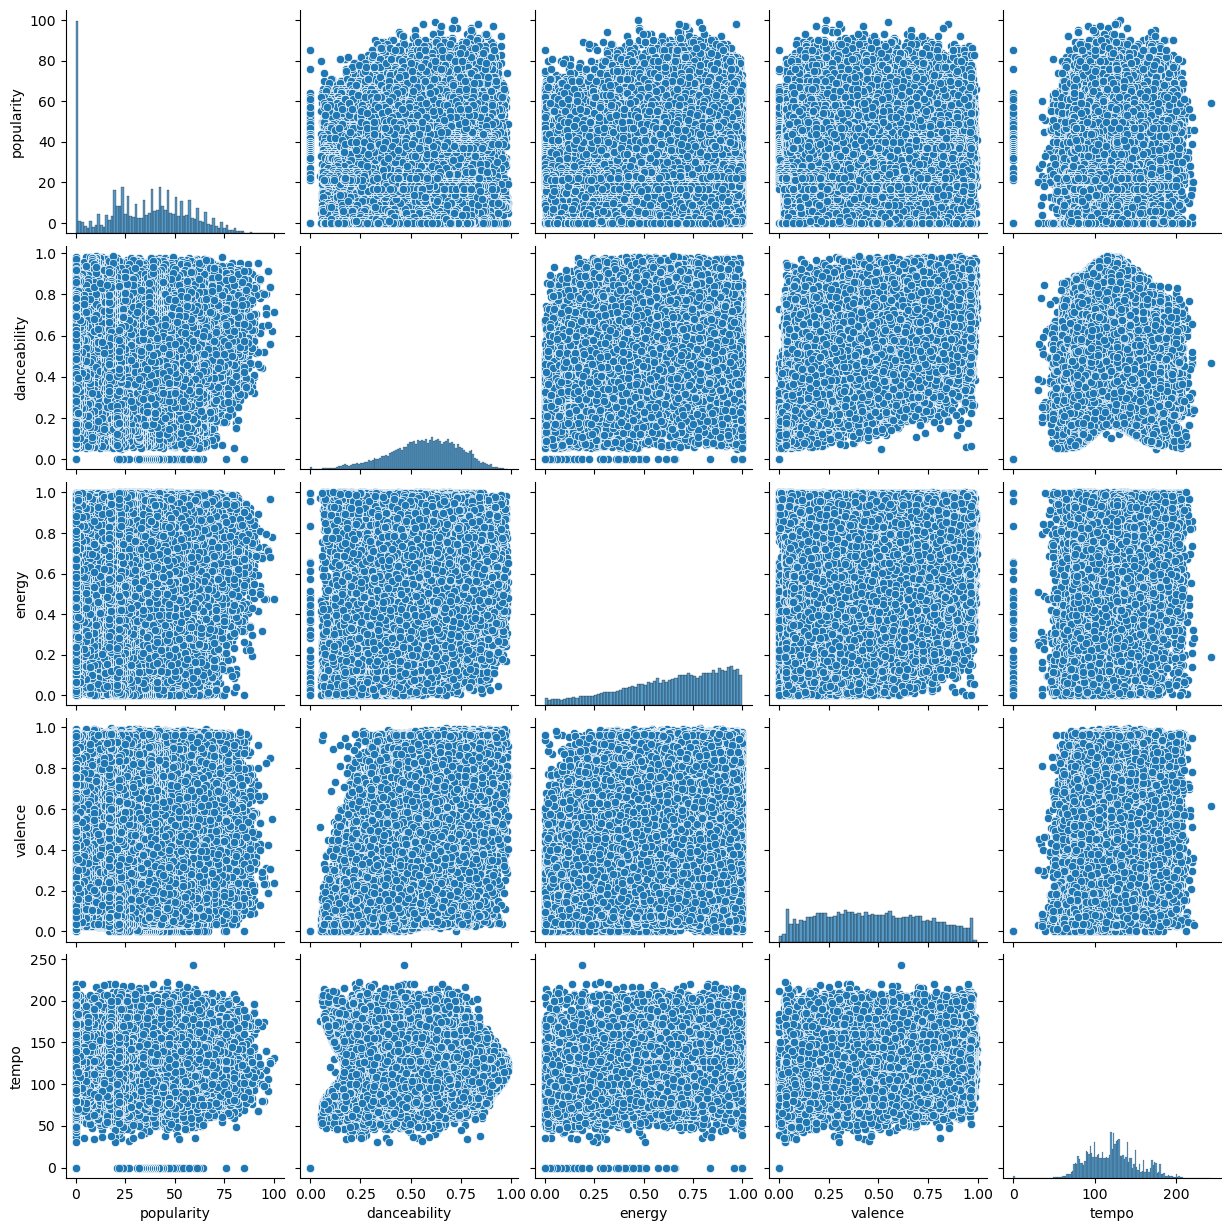

In [11]:
sns.pairplot(df[["popularity","danceability","energy","valence","tempo"]])

First using OLS, we can determine if there is a simple linear relationship between popularity and the various features of a song.

In [12]:
import statsmodels.formula.api as smf

features = ['explicit', 'danceability', 'energy', 'key', 'loudness', 
            'mode', 'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'tempo']

results = []

for f in features:
    formula = f'popularity ~ {f}'

    model = smf.ols(formula, data=popularity_filtered_df).fit()
    
    # edge case cuz explicit turns into a boolean
    if f == 'explicit':
        results.append({
        'Feature': f,
        'Coefficient': model.params['explicit[T.True]'],
        'P-Value': model.pvalues['explicit[T.True]'],
        'R-Squared': model.rsquared
        })
            
    else:
        results.append({
            'Feature': f,
            'Coefficient': model.params[f],
            'P-Value': model.pvalues[f],
            'R-Squared': model.rsquared
        })

# create table
if results:
    results_df = pd.DataFrame(results).sort_values(by='R-Squared', ascending=False)
    print(results_df.to_string(index=False))

         Feature  Coefficient       P-Value  R-Squared
instrumentalness   -11.032018  0.000000e+00   0.032980
     speechiness   -15.733471 1.773534e-176   0.008154
        loudness     0.275305 2.879005e-111   0.005114
    danceability     6.820615  2.489800e-82   0.003763
        explicit     3.738410  1.179151e-65   0.002985
        liveness    -5.103835  9.451127e-60   0.002709
          energy    -2.562905  1.253093e-25   0.001117
           tempo    -0.011609  1.420571e-08   0.000328
         valence    -0.979830  3.610558e-05   0.000174
    acousticness    -0.532001  4.233396e-03   0.000083
            mode    -0.241509  5.796449e-02   0.000037
             key    -0.016952  3.260892e-01   0.000010


Taking the sum of top features and checking their adjusted r-squared through OLS with popularity, it seems that the features that didn't increase the adjusted r-squared value was loudness, tempo, acousticness, mode, and key.

Loudness may correlate with energy, which is why adding it did not increase the adjusted r-squared any further despite having a high R-squared value on its own.

From the OLS summary below, we have an adjusted R-squared of 0.063, which means that approximately 6.3% of the variance in popularity is explained by the independent variables in our model.

It appears that the top 3 biggest factors that determine popularity are speechiness, instrumentalness, and danceability. 

Speechiness has a negative impact on popularity, telling us that the more words are being spoken in a song the less popular it is. 

Instrumentalness also has a negative impact on popularity, telling us that purely instrumental tracks have a low popularity.

Danceability has a positive impact on popularity, telling us that a highly danceable song leads to higher popularity.



In [13]:
formula = 'popularity ~ instrumentalness + speechiness + explicit + ' \
          'danceability + liveness + energy + valence'
model = smf.ols(formula, data=popularity_filtered_df).fit()
        
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     942.8
Date:                Fri, 27 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:36:42   Log-Likelihood:            -4.2536e+05
No. Observations:               97980   AIC:                         8.507e+05
Df Residuals:                   97972   BIC:                         8.508e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           43.4114      0.271  